# Controlled early-FC perturbation across independent seeds

This streamlined notebook depends only on `supp_fig4_fc_perturbation_multiseed.py`. It runs one FC-targeted rank remap and two matched rank-remap controls; the legacy intervention is excluded.

The inferential unit is the independently trained seed. Pairs are averaged within seed before confidence intervals or hypothesis tests. All IS contrasts are plotted as the raw difference `active - control`: negative values mean that active decreased IS and positive values mean that active increased IS.

In [1]:
from dataclasses import asdict, replace
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name.lower() == 'code' else cwd
CODE_DIR = PROJECT_ROOT / 'code'
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import supp_fig4_fc_perturbation_multiseed as analysis
analysis = importlib.reload(analysis)
print('Project root:', PROJECT_ROOT)
print('Analysis module:', Path(analysis.__file__).resolve())

Project root: /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP
Analysis module: /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/supp_fig4_fc_perturbation_multiseed.py


## Configuration

Set `RUN_EXPERIMENT=True` for the first run. Completed seeds are resumed automatically when `OVERWRITE_COMPLETED_SEEDS=False`. The streamlined output directory is separate from the previous five-condition run.

In [2]:
PROFILE = 'paper'                 # 'paper' or 'smoke'
RUN_EXPERIMENT = True            # set True to start/resume training
OVERWRITE_COMPLETED_SEEDS = False # keep False to resume completed seeds
DOWNLOAD_MNIST = True
DEVICE = 'auto'                   # 'auto', 'cpu', 'cuda' or 'cuda:0'
N_SEEDS = 20
N_PAIRS_PER_STRATUM = 4
TARGET_FC_SHIFT = 0.25
FC_TARGET_TOLERANCE = 0.03
CANDIDATE_DRAWS = 4               # increase only if dose/QC checks fail

if PROFILE == 'paper':
    config = analysis.paper_multiseed_config(
        PROJECT_ROOT,
        n_seeds=N_SEEDS,
        n_pairs_per_stratum=N_PAIRS_PER_STRATUM,
    )
else:
    config = analysis.smoke_multiseed_config(PROJECT_ROOT)

config = replace(
    config,
    device=DEVICE,
    target_fc_shift=TARGET_FC_SHIFT,
    fc_target_tolerance=FC_TARGET_TOLERANCE,
    candidate_draws=CANDIDATE_DRAWS if PROFILE == 'paper' else config.candidate_draws,
)
config.validate()
display(pd.Series(asdict(config), name='value').to_frame())
display(pd.Series(analysis.estimate_workload(config), name='value').to_frame())

,value
seeds,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
hidden_dims,"(100, 100)"
batch_size,256
learning_rate,0.05
total_steps,1130
intervention_start,100
intervention_end,300
record_every,5
n_pairs_per_stratum,4
selection_samples,2000


,value
n_seeds,20
pairs_per_seed,8
n_pairs_total,160
n_conditions,4
output_branches,640
trained_branches,500
scout_updates,1980
branch_updates,515500


In [3]:
if RUN_EXPERIMENT:
    results = analysis.run_resumable_experiment(
        config,
        download=DOWNLOAD_MNIST,
        overwrite=OVERWRITE_COMPLETED_SEEDS,
    )
else:
    results = analysis.load_complete_experiment(config)

(
    step_table,
    pair_table,
    final_table,
    run_summary,
    seed_summary,
    contrasts,
) = results

analysis.validate_inferential_structure(pair_table, seed_summary, config)
print('Seeds:', seed_summary['seed'].nunique())
print('Pairs:', pair_table['pair_id'].nunique())
print('Conditions:', sorted(seed_summary['condition'].unique()))

[scout] seed=0: reference training and pair selection
[scout] seed=0: selected 4 high and 4 low pairs
[seed 0: 1/25] shared untreated branch complete
[seed 0: 3/25] pair=s0_high_0_12_87 condition=independent_rank; ETA=21.0 min
[seed 0: 4/25] pair=s0_high_0_12_87 condition=corr_preserving_rank; ETA=20.1 min
[seed 0: 6/25] pair=s0_high_1_89_97 condition=independent_rank; ETA=18.0 min
[seed 0: 7/25] pair=s0_high_1_89_97 condition=corr_preserving_rank; ETA=17.1 min
[seed 0: 9/25] pair=s0_high_2_7_69 condition=independent_rank; ETA=15.1 min
[seed 0: 10/25] pair=s0_high_2_7_69 condition=corr_preserving_rank; ETA=14.2 min
[seed 0: 12/25] pair=s0_high_3_79_81 condition=independent_rank; ETA=12.2 min
[seed 0: 13/25] pair=s0_high_3_79_81 condition=corr_preserving_rank; ETA=11.3 min
[seed 0: 15/25] pair=s0_low_0_3_98 condition=independent_rank; ETA=9.5 min
[seed 0: 16/25] pair=s0_low_0_3_98 condition=corr_preserving_rank; ETA=8.6 min
[seed 0: 18/25] pair=s0_low_1_33_59 condition=independent_rank;

## 1. Direct before/after manipulation QC

Panels compare the same minibatch immediately before and after each intervention. FC is shown separately for high- and low-FC pairs. Activation mean, activation s.d., RMS logit scale and instantaneous loss are shown directly rather than only as normalized change scores. Exact marginal preservation and active-control matching remain available in the advisory QC table.

,check,observed,criterion,status
0,Exact marginal preservation,0.000000e+00,<= 1e-07,PASS
1,Relative s.d. preservation,3.360384e-17,<= 1e-06,PASS
2,Mean logit impact near target,4.289438e-02,<= 0.025,REVIEW
3,Mean sample-mapping retention near target,8.417995e-02,<= 0.1,PASS
4,Active FC shift has intended sign,1.000000e+00,>= 0.8,PASS
5,Active FC reaches untreated-anchored target,8.565433e-02,<= 0.03,REVIEW
6,high: Activation displacement matched to indep...,7.637920e-03,<= 0.0875,PASS
7,high: Activation displacement matched to corr_...,4.812168e-02,<= 0.0875,PASS
8,high: Logit displacement matched to independen...,2.159319e-03,<= 0.0125,PASS
9,high: Logit displacement matched to corr_prese...,4.563555e-03,<= 0.0125,PASS


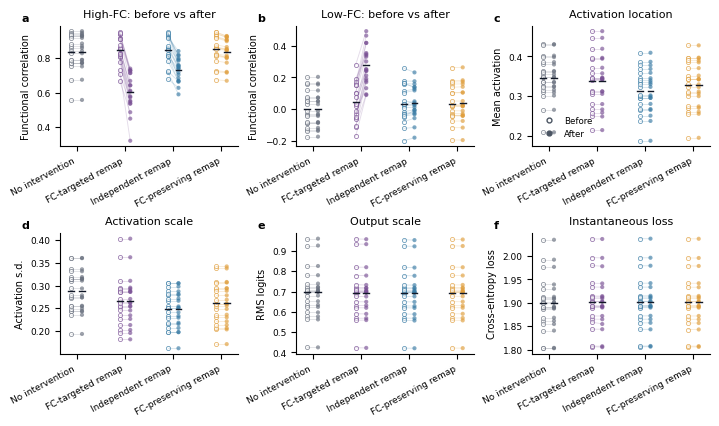

[PosixPath('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/fig/supp_fig4_fc_perturbation_multiseed_streamlined/supp_fig4_direct_before_after_qc.svg'),
 PosixPath('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/fig/supp_fig4_fc_perturbation_multiseed_streamlined/supp_fig4_direct_before_after_qc.pdf'),
 PosixPath('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/fig/supp_fig4_fc_perturbation_multiseed_streamlined/supp_fig4_direct_before_after_qc.png')]

In [4]:
qc_checks = analysis.qc_assertion_table(run_summary, config)
display(qc_checks)

figure_dir = Path(config.figure_dir)
qc_fig = analysis.make_qc_figure(seed_summary)
qc_paths = analysis.save_publication_figure(
    qc_fig, figure_dir / 'supp_fig4_direct_before_after_qc'
)
display(qc_fig)
plt.close(qc_fig)
qc_paths

## 2. Seed-level raw IS effects

All values are `active - control` without sign reversal. The expected result is negative for high-FC pairs after FC reduction and positive for low-FC pairs after FC enhancement. Each point is one independent seed after averaging the four pairs in that stratum.

,stratum,contrast,n_seeds,mean_difference,median_difference,ci95_low,ci95_high,wilcoxon_statistic,p_two_sided,p_holm
0,high,active_rank - none,20,-0.236603,-0.257495,-0.287715,-0.188319,0.0,0.000002,0.000011
1,high,active_rank - independent_rank,20,-0.212351,-0.226163,-0.252732,-0.172839,0.0,0.000002,0.000011
2,high,active_rank - corr_preserving_rank,20,-0.282487,-0.267801,-0.333980,-0.230401,0.0,0.000002,0.000011
3,low,active_rank - none,20,0.075732,0.078928,0.047884,0.103508,11.0,0.000105,0.000105
4,low,active_rank - independent_rank,20,0.065855,0.050587,0.047262,0.085836,0.0,0.000002,0.000011
5,low,active_rank - corr_preserving_rank,20,0.066878,0.057395,0.048603,0.086521,1.0,0.000004,0.000011


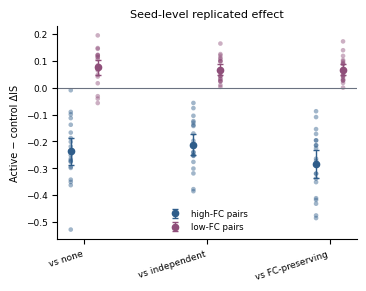

[PosixPath('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/fig/supp_fig4_fc_perturbation_multiseed_streamlined/supp_fig4_seed_level_raw_is_effect.svg'),
 PosixPath('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/fig/supp_fig4_fc_perturbation_multiseed_streamlined/supp_fig4_seed_level_raw_is_effect.pdf'),
 PosixPath('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/fig/supp_fig4_fc_perturbation_multiseed_streamlined/supp_fig4_seed_level_raw_is_effect.png')]

In [5]:
display(contrasts)
seed_fig = analysis.make_seed_effect_figure(seed_summary, config)
seed_paths = analysis.save_publication_figure(
    seed_fig, figure_dir / 'supp_fig4_seed_level_raw_is_effect'
)
display(seed_fig)
plt.close(seed_fig)
seed_paths

## 3. Cross-seed mean trajectories

Panels a and c show achieved FC relative to the matched untreated trajectory. Panels b and d show raw `active - control` IS differences. High-FC effects should therefore appear below zero and low-FC effects above zero. Lines are across-seed means after averaging pairs within seed; bands are mean ± 1.96 SEM and are descriptive rather than time-point-wise hypothesis tests.

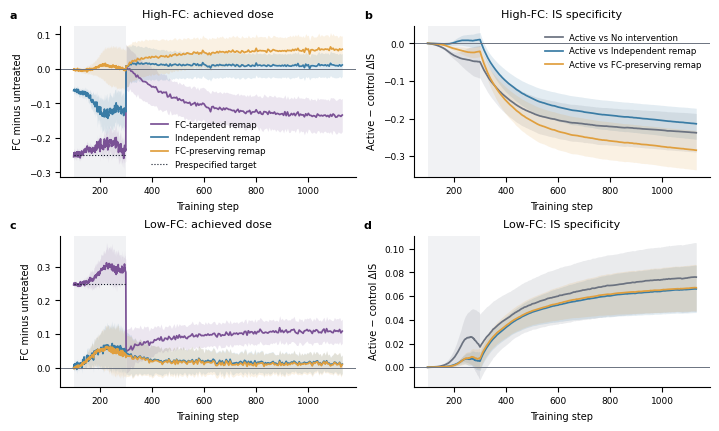

[PosixPath('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/fig/supp_fig4_fc_perturbation_multiseed_streamlined/supp_fig4_cross_seed_mean_trajectories.svg'),
 PosixPath('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/fig/supp_fig4_fc_perturbation_multiseed_streamlined/supp_fig4_cross_seed_mean_trajectories.pdf'),
 PosixPath('/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/MLP/fig/supp_fig4_fc_perturbation_multiseed_streamlined/supp_fig4_cross_seed_mean_trajectories.png')]

In [6]:
trajectory_fig = analysis.make_reference_effect_figure(step_table, config)
trajectory_paths = analysis.save_publication_figure(
    trajectory_fig, figure_dir / 'supp_fig4_cross_seed_mean_trajectories'
)
display(trajectory_fig)
plt.close(trajectory_fig)
trajectory_paths